# Classification Models - Part A
This notebook trains and evaluates the classification algorithms for Part A of the Capstone Project.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Set display options and random seed
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

## 1. Load Preprocessed Data
We load the scaled and encoded datasets from the `data/classification/` directory.

In [11]:
X_train = pd.read_csv('../data/classification/X_train.csv')
X_test = pd.read_csv('../data/classification/X_test.csv')
y_train = pd.read_csv('../data/classification/y_train.csv').squeeze()
y_test = pd.read_csv('../data/classification/y_test.csv').squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (94337, 92)
X_test shape: (23585, 92)


## 2. Logistic Regression (Baseline Classifier)
Logistic Regression is inherently a binary classification algorithm. To apply it to our multi-class target (`Attack_type_encoded`), we use the One-vs-Rest (OvR) strategy via `OneVsRestClassifier`.

In [12]:
# Initialize and train the Logistic Regression model using One-vs-Rest wrapper
base_log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg = OneVsRestClassifier(base_log_reg)
log_reg.fit(X_train, y_train)

# Generate predictions
y_pred_logreg = log_reg.predict(X_test)
y_pred_proba_logreg = log_reg.predict_proba(X_test)

### Evaluation Metrics

In [13]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='weighted')
    
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': roc_auc}

metrics_logreg = evaluate_model(y_test, y_pred_logreg, y_pred_proba_logreg, "Logistic Regression")

--- Logistic Regression ---
Accuracy:  0.9947
Precision: 0.9947
Recall:    0.9947
F1 Score:  0.9947
ROC-AUC:   0.9996


### Confusion Matrix

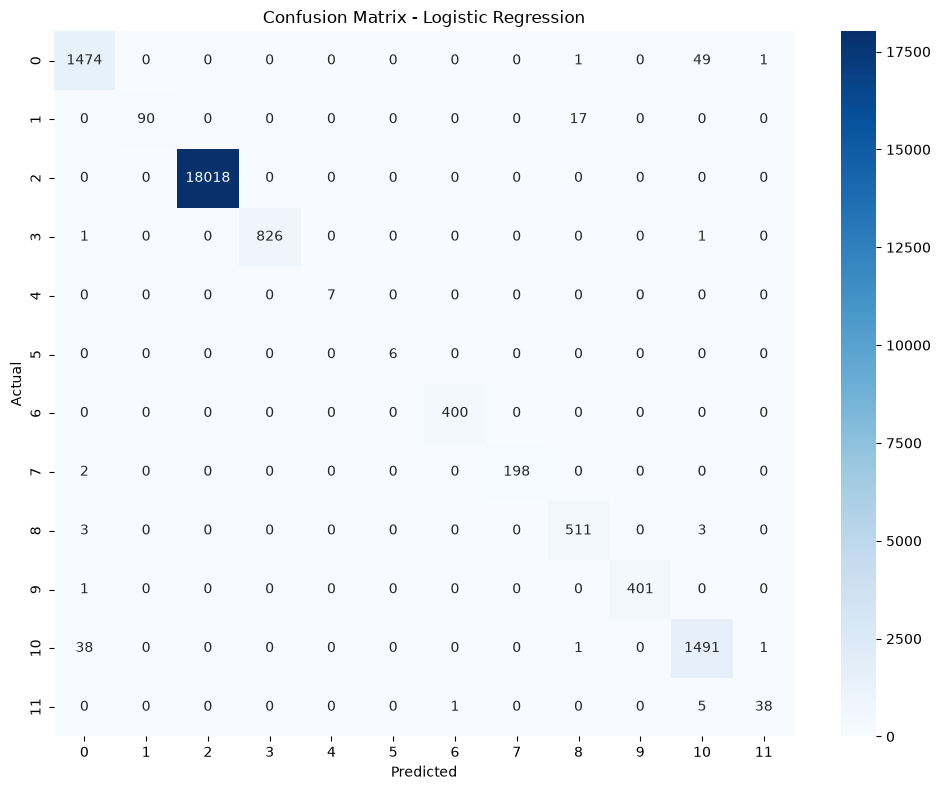

In [14]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Interpreting Coefficients (Odds Ratios)
Using `OneVsRestClassifier`, we train a separate logistic regression model for each class. We can inspect the coefficients of the first model (Class 0 vs Rest). The coefficients represent the log-odds. By exponentiating them, we get the **odds ratios**. An odds ratio > 1 means the feature increases the probability of the class, while < 1 decreases it.

In [15]:
# Extract coefficients for the first class (Class 0 vs Rest)
coefficients = log_reg.estimators_[0].coef_[0]
odds_ratios = np.exp(coefficients)

# Create a DataFrame for interpretation
feature_names = X_train.columns
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients, 'Odds_Ratio': odds_ratios})

# Show top 5 features that positively influence Class 0 vs Rest
print("Top 5 Features positively influencing Class 0 vs Rest:")
display(coef_df.sort_values(by='Odds_Ratio', ascending=False).head(5))

Top 5 Features positively influencing Class 0 vs Rest:


,Feature,Coefficient,Odds_Ratio
13,fwd_header_size_max,6.327009,559.480677
84,service_dns,2.889505,17.984404
26,fwd_pkts_payload.min,2.725514,15.264255
12,fwd_header_size_min,2.370235,10.699908
69,active.tot,2.249429,9.482318
